In [ ]:
import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Załaduj zestaw walidacyjny/testowy z oryginalnymi opisami
# Zakładamy, że masz plik JSON z parami {'image_name': [list_of_captions]}
with open('../dataset/caption_datasets/dataset_coco.json', 'r') as j:
    data = json.load(j)

# Tworzymy słownik: nazwa pliku -> lista opisów (tokenizowanych)
img_references = {}
for img in data['images']:
    if img['split'] in {'val', 'test'}:
        # Pobieramy same teksty opisów i dzielimy na słowa
        img_references[img['filename']] = [c['tokens'] for c in img['sentences']]

cc = SmoothingFunction()

def calculate_bleu(reference, candidate):
    # Liczymy BLEU-4 (średnia geometryczna z 1, 2, 3 i 4-gramów)
    return sentence_bleu(reference, candidate, smoothing_function=cc.method1)

In [13]:
# Wczytanie mapy słów
with open(word_map_path, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

def decode_caption(seq):
    """Zamienia listę indeksów na czytelne zdanie, pomijając tagi specjalne."""
    words = [rev_word_map[ind] for ind in seq if ind not in 
             {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
    return " ".join(words)

In [14]:
import pandas as pd
import time

# Wybierz obrazek do testów
img_test = "../dataset/val2014/COCO_val2014_000000000042.jpg"

beam_sizes = [1, 3, 5, 10, 20]
results = []

print(f"Rozpoczynam eksperyment dla obrazka: {os.path.basename(img_test)}\n")

for k in beam_sizes:
    start_time = time.time()
    
    # Generowanie opisu za pomocą Beam Search
    # Zauważ: alphas to mapy atencji, których użyjemy później
    seq, alphas = caption_image_beam_search(encoder, decoder, img_test, word_map, k)
    
    end_time = time.time()
    
    caption = decode_caption(seq)
    results.append({
        "Beam Size (k)": k,
        "Generated Caption": caption,
        "Time (s)": round(end_time - start_time, 4),
        "Length": len(caption.split())
    })

# Wyświetlenie wyników w formie tabeli
df = pd.DataFrame(results)
display(df)

Rozpoczynam eksperyment dla obrazka: COCO_val2014_000000000042.jpg



,Beam Size (k),Generated Caption,Time (s),Length
0,1,a teddy bear sitting on a shelf with a pair of...,0.7102,12
1,3,a teddy bear sitting on a shelf in a room,0.0851,10
2,5,a teddy bear is sitting on a shelf,0.0363,8
3,10,a teddy bear is sitting on a shelf,0.0410,8
4,20,a teddy bear is sitting on a shelf,0.0635,8


Wizualizacja atencji dla k=5:


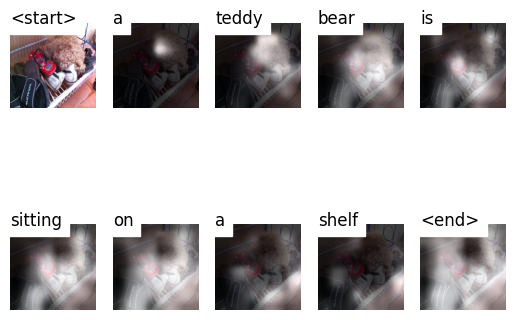

In [15]:
from caption import visualize_att

# Ponowne generowanie dla k=5, aby pobrać mapy atencji (alphas)
k_final = 5
seq, alphas = caption_image_beam_search(encoder, decoder, img_test, word_map, k_final)

# Konwersja alphas na tensor, jeśli funkcja tego wymaga (zależy od Twojej wersji caption.py)
alphas_tensor = torch.FloatTensor(alphas)

print(f"Wizualizacja atencji dla k={k_final}:")
visualize_att(img_test, seq, alphas_tensor, rev_word_map, smooth=True)